In [102]:
import numpy as np
from matplotlib import pyplot as plt
import uproot
import awkward as ak

In [103]:
def cov_universe(y_u: np.ndarray) -> float:
    """
    Universe covariance for a 1-bin quantity.
    y_u shape: (U,)
    Returns sample variance across universes.
    """
    return np.var(y_u, ddof=1)

def cov_universe_xy(x_u: np.ndarray, y_u: np.ndarray) -> float:
    """
    Cross-covariance across universes.
    """
    x = x_u - x_u.mean()
    y = y_u - y_u.mean()
    return (x @ y) / (len(x_u) - 1)

In [104]:
def run_test(seed=0, n_events=5000, n_univ=100):
    rng = np.random.default_rng(seed)

    # "Denominator events": each event has a universe-weight vector w_i[u]
    # Make weights event-dependent AND correlated across universes to be realistic.
    base = rng.lognormal(mean=0.0, sigma=0.2, size=(n_events, 1))
    univ_fluct = rng.normal(loc=0.0, scale=0.05, size=(1, n_univ))
    event_fluct = rng.normal(loc=0.0, scale=0.02, size=(n_events, n_univ))
    W = base * (1.0 + univ_fluct + event_fluct)  # shape (N, U)

    # Define a numerator subset mask (e.g. tighter selection)
    # Here: select events with high "score"
    score = rng.normal(size=n_events)
    mask_num = score > 0.7  # ~24% pass, subset of denominator

    # ---- Method A: "masking" approach ----
    D_u = W.sum(axis=0)                  # (U,)
    N_u = W[mask_num].sum(axis=0)        # (U,)
    eps_u = N_u / D_u

    # ---- Method B: explicit loop (should match A) ----
    D2 = np.zeros(n_univ)
    N2 = np.zeros(n_univ)
    for i in range(n_events):
        wi = W[i]
        D2 += wi
        if mask_num[i]:
            N2 += wi
    eps2 = N2 / D2

    # Check equivalence (numerical)
    print("max |D_u - D2|   =", np.max(np.abs(D_u - D2)))
    print("max |N_u - N2|   =", np.max(np.abs(N_u - N2)))
    print("max |eps_u-eps2| =", np.max(np.abs(eps_u - eps2)))

    # ---- Show why you need joint info (Cov(N,D)) ----
    varN = cov_universe(N_u)
    varD = cov_universe(D_u)
    covND = cov_universe_xy(N_u, D_u)

    eps_nom = N_u.mean() / D_u.mean()
    print("\nNominal efficiency (mean-universe ratio):", eps_nom)

    # Delta-method approximation for Var(eps) using Var(N), Var(D), Cov(N,D)
    # Var(N/D) ≈ (1/D^2)Var(N) + (N^2/D^4)Var(D) - 2N/(D^3)Cov(N,D)
    Nbar = N_u.mean()
    Dbar = D_u.mean()
    var_eps_delta = (varN / (Dbar**2)) + (Nbar**2 * varD / (Dbar**4)) - (2 * Nbar * covND / (Dbar**3))

    # "Truth" from universes directly
    var_eps_direct = cov_universe(eps_u)

    print("\nVar(eps) direct from universes:", var_eps_direct)
    print("Var(eps) delta-method w/ Cov(N,D):", var_eps_delta)

    # What happens if you (incorrectly) ignore Cov(N,D)
    var_eps_no_cov = (varN / (Dbar**2)) + (Nbar**2 * varD / (Dbar**4))
    print("Var(eps) delta-method w/o Cov(N,D):", var_eps_no_cov)

In [105]:
run_test()

max |D_u - D2|   = 0.0
max |N_u - N2|   = 0.0
max |eps_u-eps2| = 0.0

Nominal efficiency (mean-universe ratio): 0.24236306021159254

Var(eps) direct from universes: 1.386903540666808e-08
Var(eps) delta-method w/ Cov(N,D): 1.4105917626398411e-08
Var(eps) delta-method w/o Cov(N,D): 0.00029782133989989543


In [315]:
def efficiency_covariance_per_bin(x, w_univ, mask_den, mask_num, bin_edges, eps=0.0):
    """
    x:        (N,) plot variable
    w_univ:   (N, U) per-event weights for a *single systematic source*
    mask_den: (N,) boolean denominator selection
    mask_num: (N,) boolean numerator selection (subset of mask_den)
    bin_edges:(B+1,)
    returns: (E_mean[B], Cov[B,B], E_univ[U,B])
    """
    assert w_univ.ndim == 2
    N, U = w_univ.shape
    B = len(bin_edges) - 1

    # bin index per event: 0..B-1, or -1 if out of range
    b = np.digitize(x, bin_edges) - 1
    in_range = (b >= 0) & (b < B)

    # allocate per-universe, per-bin numerator/denominator
    N_ub = np.zeros((U, B), dtype=float)
    D_ub = np.zeros((U, B), dtype=float)

    print(f"debug efficiency_covariance_per_bin: numerator: {np.count_nonzero(mask_num)}, denominator: {np.count_nonzero(mask_den)}")

    # Fill by bin (vectorized over universes)
    for bi in range(B):
        sel_den = in_range & mask_den & (b == bi)
        sel_num = in_range & mask_num & (b == bi)

        # sum over events; keep universe axis
        if np.any(sel_den):
            D_ub[:, bi] = w_univ[sel_den].sum(axis=0)
        if np.any(sel_num):
            N_ub[:, bi] = w_univ[sel_num].sum(axis=0)

    # efficiency per universe per bin
    E_ub = np.zeros((U, B), dtype=float)
    good = D_ub > 0
    E_ub[good] = N_ub[good] / D_ub[good]
    # if D==0, keep 0 (or np.nan); choose consistent convention
    if eps is not None:
        E_ub[~good] = eps

    print("mean numerator per bin:", N_ub.mean(axis=0))
    print("mean denominator per bin:", D_ub.mean(axis=0))
    print("mean efficiency per bin:", E_ub.mean(axis=0))

    print("Numerator universes:", N_ub)
    print("Denominator universes:", D_ub)

    # mean across universes per bin
    E_mean = E_ub.mean(axis=0)

    # covariance across universes (bins x bins)
    # np.cov expects variables in rows by default; set rowvar=False
    Cov = np.cov(E_ub, rowvar=False, ddof=1)

    return E_mean, Cov, E_ub

In [175]:
def demo(seed=123, n_events=20000, n_univ=50):
    rng = np.random.default_rng(seed)

    # plot variable
    x = rng.uniform(0.0, 3.0, size=n_events)

    # selections: numerator subset of denominator
    mask_den = x > 0.2
    mask_num = mask_den & (rng.random(n_events) < (0.2 + 0.25 * (x / 3.0)))

    # per-event per-universe weights
    base = rng.lognormal(mean=0.0, sigma=0.45, size=(n_events, 1))
    global_shift = rng.normal(0.0, 0.5, size=(1, n_univ))
    event_shift = rng.normal(0.0, 0.5, size=(n_events, n_univ))
    w_univ = base * (1.0 + global_shift + event_shift)

    bin_edges = np.linspace(0.0, 3.0, 11)  # 10 bins
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_halfwidth = 0.5 * (bin_edges[1:] - bin_edges[:-1])

    E_mean, Cov, _ = efficiency_covariance_per_bin(
        x=x,
        w_univ=w_univ,
        mask_den=mask_den,
        mask_num=mask_num,
        bin_edges=bin_edges,
        eps=0.0,
    )

    sigma = np.sqrt(np.clip(np.diag(Cov), 0.0, None))

    fig, ax = plt.subplots(figsize=(12, 8))

    # central values with x error bars showing bin width
    ax.errorbar(
        bin_centers, E_mean,
        xerr=bin_halfwidth,
        fmt="o", color="black",
        label="Efficiency (mean across universes)",
        capsize=2,
    )

    # 1σ band (diagonal-only). This is the standard “error band”.
    ax.fill_between(
        bin_centers,
        E_mean - sigma,
        E_mean + sigma,
        color="C0", alpha=0.25,
        label=r"Systematic 1$\sigma$ band",
        step=None,
    )

    ax.set_xlabel("x (plot variable)")
    ax.set_ylabel("Efficiency")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

debug efficiency_covariance_per_bin: numerator: 6245, denominator: 18711


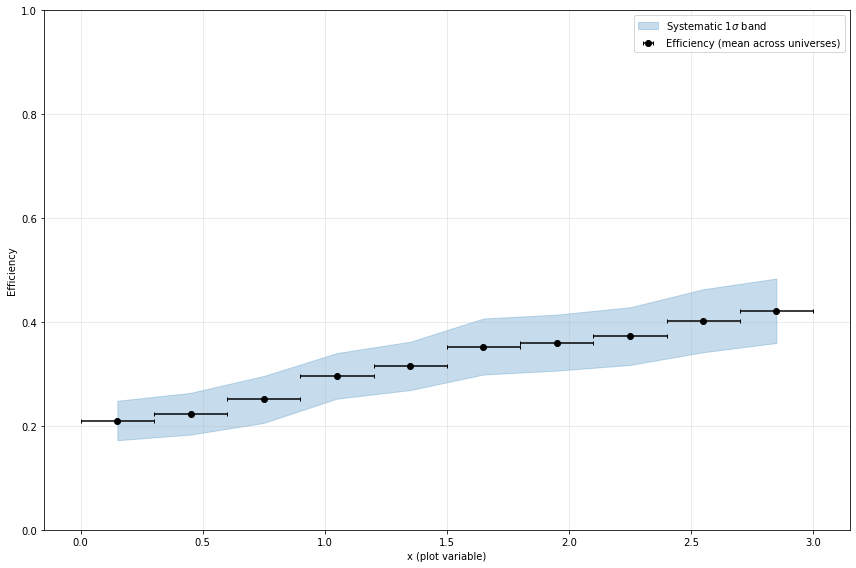

In [176]:
demo()

### try with a root file

In [177]:
f_multisim = uproot.open('/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive_trueSignal2.root:events/NuMIFull/true_signal_NuMIfluxsimTree')

In [178]:
f_multisim.keys()

['hysyst_beam_horn_2kA_v',
 'hysyst_beam_horn1_x_3mm_v',
 'hysyst_beam_horn1_y_3mm_v',
 'hysyst_beam_spot_1_3mm_v',
 'hysyst_beam_spot_1_7mm_v',
 'hysyst_beam_horn2_x_3mm_v',
 'hysyst_beam_horn2_y_3mm_v',
 'hysyst_beam_horns_0mm_water_v',
 'hysyst_beam_horns_2mm_water_v',
 'hysyst_beam_Beam_shift_x_1mm_v',
 'hysyst_beam_Beam_shift_y_1mm_v',
 'hysyst_beam_Target_z_7mm_v',
 'hysyst_hpc_0_v',
 'hysyst_hpc_1_v',
 'hysyst_hpc_2_v',
 'hysyst_hpc_3_v',
 'hysyst_hpc_4_v',
 'hysyst_hpc_5_v',
 'hysyst_hpc_6_v',
 'hysyst_hpc_7_v',
 'hysyst_hpc_8_v',
 'hysyst_hpc_9_v',
 'hysyst_hpc_10_v',
 'hysyst_hpc_11_v',
 'hysyst_hpc_12_v',
 'hysyst_hpc_13_v',
 'hysyst_hpc_14_v',
 'hysyst_beam_horn_2kA_sigma',
 'hysyst_beam_horn1_x_3mm_sigma',
 'hysyst_beam_horn1_y_3mm_sigma',
 'hysyst_beam_spot_1_3mm_sigma',
 'hysyst_beam_spot_1_7mm_sigma',
 'hysyst_beam_horn2_x_3mm_sigma',
 'hysyst_beam_horn2_y_3mm_sigma',
 'hysyst_beam_horns_0mm_water_sigma',
 'hysyst_beam_horns_2mm_water_sigma',
 'hysyst_beam_Beam_shift_x_

In [179]:
flux_skin = f_multisim['hysyst_beam_horn_2kA_v'].array()



In [330]:
def read_weights_matrix(root_path, event_tree_path, syst_tree_path, syst_branch, x_branch, mask=None):
    """
    Returns:
      x: (N,)
      W: (N, U)
      key: (N,3) of (Run,Subrun,Evt) for safety
    If `mask` is provided (boolean length N), returns only masked entries.
    """
    with uproot.open(root_path) as f:
        tev = f[event_tree_path]
        tsys = f[syst_tree_path]

        # metadata keys for alignment
        run = tev["Run"].array(library="np")
        subrun = tev["Subrun"].array(library="np")
        evt = tev["Evt"].array(library="np")
        key = np.stack([run, subrun, evt], axis=1)

        x = tev[x_branch].array(library="np")

        # This is jagged: list-of-lists (N entries, each is length U)
        w_jagged = tsys[syst_branch].array(library="np")

        # Convert to a dense (N,U). Assumes constant U per event for that syst.
        U = len(w_jagged[0])
        W = np.vstack([np.asarray(w, dtype=float) for w in w_jagged])
        assert W.shape == (len(x), U)

        if mask is not None:
            mask = np.asarray(mask, dtype=bool)
            if mask.shape != (len(x),):
                raise ValueError(f"mask must have shape ({len(x)},); got {mask.shape}")
            x = x[mask]
            key = key[mask]
            W = W[mask]

        return x, W, key

SIGMA_KNOTS_7 = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

def read_spline_universes(
    root_path,
    event_tree_path,
    syst_tree_path,
    syst_branch,
    x_branch,
    nuniv=1000,
    seed=None,
    sigma_levels=None,
    check_keys=False,
    mask=None,
    return_sigmas=False,
 ):
    """
    Read per-event multisigma "spline knot" weights from a ROOT file and convert
    them into per-event pseudo-universe weights using the SAME behavior as
    medulla/spineplot/systematic.py:

      - draw sigma ~ N(0,1) independently for each (event, universe)
      - interpolate each event's K-point curve with np.interp
        (np.interp clamps outside the knot range to the endpoints)

    IMPORTANT for matching Systematic:
      If you want identical universes, apply the SAME mask before generating
      random sigmas. Pass `mask=mask_den` (or whatever base selection you use).

    Parameters
    ----------
    root_path : str
    event_tree_path : str
        Path to the event tree (where Run/Subrun/Evt and x_branch live).
    syst_tree_path : str
        Path to the syst tree (where syst_branch lives).
    syst_branch : str
        Branch name containing per-entry vectors of length K (K=6 or 7 typical).
    x_branch : str
        Branch name for the plotting/binning variable.
    nuniv : int
        Number of pseudo-universes to generate.
    seed : int or None
        RNG seed for reproducibility.
    sigma_levels : array-like or None
        If provided, length K giving the sigma positions of the K weights.
        If None:
          - K=7 assumes [3, 2, 1, 0, -1, -2, -3] (as in Systematic)
          - K=6 assumes GENIE ordering [-1,+1,-2,+2,-3,+3] then sorts.
    check_keys : bool
        If True, asserts that (Run,Subrun,Evt) match between event and syst trees.
    mask : array-like of bool or None
        If provided, boolean mask over event-tree rows. The spline universes are
        generated ONLY for masked entries (this matches Systematic behavior when
        it builds universes after masking).
    return_sigmas : bool
        If True, also return the random sigma draws used for interpolation.

    Returns
    -------
    x : np.ndarray, shape (N_sel,)
    W_univ : np.ndarray, shape (N_sel, nuniv)
        Per-event per-universe weights.
    key : np.ndarray, shape (N_sel,3)
        (Run, Subrun, Evt)
    random_sigmas : np.ndarray, shape (N_sel, nuniv)
        Only returned if return_sigmas=True.
    """
    with uproot.open(root_path) as f:
        tev = f[event_tree_path]
        tsys = f[syst_tree_path]

        run = tev["Run"].array(library="np")
        subrun = tev["Subrun"].array(library="np")
        evt = tev["Evt"].array(library="np")
        key = np.stack([run, subrun, evt], axis=1)

        x = tev[x_branch].array(library="np")

        # Per-entry vectors (jagged list-of-lists, but typically fixed length K)
        w_jagged = tsys[syst_branch].array(library="np")

        # Optional alignment check
        if check_keys:
            run_s = tsys["Run"].array(library="np")
            subrun_s = tsys["Subrun"].array(library="np")
            evt_s = tsys["Evt"].array(library="np")
            key_s = np.stack([run_s, subrun_s, evt_s], axis=1)
            if key_s.shape != key.shape or not np.all(key_s == key):
                raise ValueError("Event tree and syst tree entries are not aligned by (Run,Subrun,Evt).")

    # Dense (N, K)
    K = len(w_jagged[0])
    Wpts = np.vstack([np.asarray(w, dtype=float) for w in w_jagged])
    if Wpts.shape[0] != len(x):
        raise ValueError(f"Weight/event length mismatch: Wpts has N={Wpts.shape[0]}, x has N={len(x)}")

    # Apply mask BEFORE generating universes (to match Systematic RNG consumption/order)
    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != (len(x),):
            raise ValueError(f"mask must have shape ({len(x)},); got {mask.shape}")
        x = x[mask]
        key = key[mask]
        Wpts = Wpts[mask]

    # Determine sigma_levels and reorder weights as needed (match Systematic.get_universe_weights)
    if sigma_levels is None:
        if K == 7:
            # Match Systematic: sigma levels in descending order (3 -> -3)
            sigma_levels = np.array([3, 2, 1, 0, -1, -2, -3], dtype=float)
            W = Wpts
        elif K == 6:
            sigma_levels_raw = np.array([-1, 1, -2, 2, -3, 3], dtype=float)
            order = np.argsort(sigma_levels_raw)
            sigma_levels = sigma_levels_raw[order]
            W = Wpts[:, order]
        else:
            raise ValueError(f"Expected K=6 or K=7 if sigma_levels is None; got K={K}")
    else:
        sigma_levels = np.asarray(sigma_levels, dtype=float)
        if sigma_levels.shape != (K,):
            raise ValueError(f"sigma_levels must have shape ({K},); got {sigma_levels.shape}")
        order = np.argsort(sigma_levels)
        sigma_levels = sigma_levels[order]
        W = Wpts[:, order]

    # Sample sigma ~ N(0,1) per (event, universe), then interpolate per event
    rng = np.random.default_rng(seed)
    random_sigmas = rng.normal(0.0, 1.0, size=(W.shape[0], nuniv))

    W_univ = np.empty((W.shape[0], nuniv), dtype=float)
    for i in range(W.shape[0]):
        W_univ[i] = np.interp(random_sigmas[i], sigma_levels, W[i])

    if return_sigmas:
        return x, W_univ, key, random_sigmas
    return x, W_univ, key

In [306]:
plotVar2, flux_hornC_w, key = read_weights_matrix(
    root_path='/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive_trueSignal.root',
    event_tree_path='events/NuMIFull/true_signal',
    syst_tree_path='events/NuMIFull/true_signal_multisimTree',
    syst_branch='horncurrent_Flux',
    x_branch='reco_leading_electron_energy',
)

In [334]:
#get another branch to select numerator events

f_events = uproot.open('/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive_trueSignal2.root:events/NuMIFull/true_signal')

print(f_events.keys())

fiducial_cut = f_events['reco_fiducial_cut'].array(library="np").astype(bool)
containment_cut = f_events['reco_containment_cut'].array(library="np").astype(bool)
flash_cut = f_events['reco_flash_cut'].array(library="np").astype(bool)

nan_mask = np.isnan(f_events['reco_fiducial_cut'].array(library="np")) | np.isnan(f_events['reco_containment_cut'].array(library="np")) | \
            np.isnan(f_events['reco_flash_cut'].array(library="np")) | np.isnan(f_events['true_neutrino_energy'].array(library="np")) | \
            np.isnan(f_events['reco_leading_electron_ke'].array(library="np")) | np.isnan(f_events['reco_leading_electron_energy'].array(library="np")) | \
            np.isnan(f_events['reco_ele_beam_open_angle'].array(library="np")) | np.isnan(f_events['reco_containment_cut'].array(library="np")) | \
            np.isnan(f_events['reco_has_particle_multiplicity'].array(library="np")) | np.isnan(f_events['reco_no_muons'].array(library="np"))
            
sel_mask = containment_cut & flash_cut & fiducial_cut

['reco_containment_cut', 'reco_cut_type', 'reco_ele_beam_open_angle', 'reco_electron_multiplicity', 'reco_electron_softmax_cut', 'reco_fiducial_cut', 'reco_flash_cut', 'reco_flash_time', 'reco_has_particle_multiplicity', 'reco_is_data', 'reco_is_nu', 'reco_leading_ele_energy_cut', 'reco_leading_electron_axial_spread', 'reco_leading_electron_azimuthal_angle', 'reco_leading_electron_calo_ke', 'reco_leading_electron_containment_cut', 'reco_leading_electron_csda_ke', 'reco_leading_electron_directional_spread', 'reco_leading_electron_electron_softmax', 'reco_leading_electron_end_dir_x', 'reco_leading_electron_end_dir_y', 'reco_leading_electron_end_dir_z', 'reco_leading_electron_end_x', 'reco_leading_electron_end_y', 'reco_leading_electron_end_z', 'reco_leading_electron_energy', 'reco_leading_electron_ke', 'reco_leading_electron_length', 'reco_leading_electron_mcs_ke', 'reco_leading_electron_mip_softmax', 'reco_leading_electron_muon_softmax', 'reco_leading_electron_p', 'reco_leading_electron

In [336]:
a_leading_electron_energy = f_events['true_leading_electron_energy'].array(library="np")
true_category = f_events['true_category'].array(library="np")
reco_reco_interaction_type = f_events['reco_reco_interaction_type'].array(library="np")

reco_reco_interaction_type = np.where(true_category == 0, reco_reco_interaction_type, -1)

print(ak.where(np.isnan(reco_reco_interaction_type)))

reco_sel = (reco_reco_interaction_type == 1)

print(len(a_leading_electron_energy), len(true_category), len(reco_reco_interaction_type))
valid = np.ones_like(a_leading_electron_energy, dtype=bool)  # placeholder; replace with actual valid event mask if needed
reco_category = np.where(true_category == 0, reco_reco_interaction_type, -1)
print(ak.where(np.isnan(reco_category)))
mask_den = valid & reco_sel & ~nan_mask # denominator: valid events + reco category 1 (CC1p0pi)
mask_num = valid & reco_sel & sel_mask & ~nan_mask       # example numerator; adjust threshold as needed

(<Array [1702] type='1 * int64'>,)
2830 2830 2830
(<Array [1702] type='1 * int64'>,)


In [343]:
# Generate spline pseudo-universes ONLY for denominator-selected events (matches Systematic)
plotVar_den, flux_skin_w_den, key_den = read_spline_universes(
    root_path='/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive_trueSignal2.root',
    event_tree_path='events/NuMIFull/true_signal',
    syst_tree_path='events/NuMIFull/true_signal_NuMIfluxsimTree',
    syst_branch='hysyst_beam_horn_2kA_v',
    x_branch='true_leading_electron_energy',
    nuniv=1000,
    seed=12345,
    mask=mask_den,
 )

plotVar_den2, flux2, key_den2 = read_spline_universes(
    root_path='/nashome/m/micarrig/icarus/nuESpine/gundam_nueCCInclusive_trueSignal2.root',
    event_tree_path='events/NuMIFull/true_signal',
    syst_tree_path='events/NuMIFull/true_signal_NuMIfluxsimTree',
    syst_branch='hysyst_beam_horn1_x_3mm_v',
    x_branch='true_leading_electron_energy',
    nuniv=1000,
    seed=12345,
    mask=mask_den,
)


# Masks reduced to denominator base, just like Systematic does internally
mask_den_base = np.ones_like(plotVar_den, dtype=bool)
mask_num_base = mask_num[mask_den]

print("Masked shapes:", plotVar_den.shape, flux_skin_w_den.shape, mask_num_base.shape)

Masked shapes: (991,) (991, 1000) (991,)


In [338]:
bin_edges = [225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]
bin_edges = np.asarray(bin_edges, dtype=float)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_halfwidth = 0.5 * (bin_edges[1:] - bin_edges[:-1])

a_leading_electron_energy = np.where(a_leading_electron_energy > 5000, 5_000, a_leading_electron_energy)

num_cv = np.histogram(a_leading_electron_energy[mask_num], bins=bin_edges)[0]
den_cv = np.histogram(a_leading_electron_energy[mask_den], bins=bin_edges)[0]

eff_cv = num_cv / den_cv

print("Efficiency CV:", eff_cv)
print("Denominator CV:", den_cv, den_cv.sum(), np.count_nonzero(mask_den))
print("Numerator CV:", num_cv, num_cv.sum(), np.count_nonzero(mask_num))

Efficiency CV: [0.96460177 0.94957983 0.94964029 0.96521739 0.984      1.
 0.97938144 0.95604396 0.95238095]
Denominator CV: [113 119 139 115 125 129  97  91  63] 991 991
Numerator CV: [109 113 132 111 123 129  95  87  60] 959 959


In [339]:
# Use the denominator-masked universes + base-reduced masks (matches Systematic)
E_mean, Cov, E_ub = efficiency_covariance_per_bin(
    plotVar_den,
    flux_skin_w_den,
    mask_den=mask_den_base,
    mask_num=mask_num_base,
    bin_edges=bin_edges,
 )
print(E_mean)
print(Cov)

debug efficiency_covariance_per_bin: numerator: 959, denominator: 991
mean numerator per bin: [107.77441494 112.14598874 130.73884795 109.94703809 121.75438675
 128.02203578  94.99863724  87.89656283  59.63662272]
mean denominator per bin: [111.71644018 118.11495104 137.74513658 113.87162379 123.73164847
 128.02203578  97.02713181  92.07636463  62.70934281]
mean efficiency per bin: [0.96471401 0.9494648  0.94913585 0.965535   0.98401976 1.
 0.97909353 0.95460505 0.95100061]
Numerator universes: [[107.77440119 112.14565784 130.73899859 ...  94.99968189  87.89683759
   59.63633567]
 [107.77440119 112.14565784 130.73899859 ...  94.99968189  87.89683759
   59.63633567]
 [107.77440119 112.14109403 130.73899859 ...  94.99968189  87.89906412
   59.63633567]
 ...
 [107.77440119 112.14565784 130.73899859 ...  94.99968189  87.89683759
   59.60963351]
 [107.77772939 112.12908924 130.73899859 ...  94.99968189  87.89683759
   59.62885779]
 [107.77440119 112.14565784 130.73899859 ...  94.99968189  8

In [346]:
E_mean2, Cov2, _ = efficiency_covariance_per_bin(
    plotVar_den2, 
    flux2, 
    mask_den=mask_den_base, 
    mask_num=mask_num_base, 
    bin_edges=bin_edges,
)

debug efficiency_covariance_per_bin: numerator: 959, denominator: 991
mean numerator per bin: [107.83819826 112.03848461 131.12718247 111.00003894 123.03559076
 129.25226538  94.71324342  87.97385515  58.93258442]
mean denominator per bin: [111.82614011 117.96712511 138.05946049 114.941039   125.04138084
 129.25226538  96.70009488  92.03407908  61.92225938]
mean efficiency per bin: [0.96433802 0.94974328 0.94978774 0.96571285 0.98395899 1.
 0.97945347 0.95588347 0.95171889]
Numerator universes: [[107.83798373 112.03782499 131.12696368 ...  94.71356088  87.97352046
   58.93194592]
 [107.83798373 112.03782499 131.12696368 ...  94.71356088  87.97352046
   58.93194592]
 [107.83798373 112.01967978 131.12696368 ...  94.71356088  87.95300293
   58.93194592]
 ...
 [107.83798373 112.03782499 131.12696368 ...  94.71356088  87.97352046
   58.95360035]
 [107.85387218 112.02936542 131.12696368 ...  94.71356088  87.97352046
   59.03313923]
 [107.83798373 112.03782499 131.12696368 ...  94.71356088  8

In [349]:
CovTotal = Cov + Cov2
# CovTotal = Cov

std = np.sqrt(np.diag(CovTotal))
corr = CovTotal / np.outer(std, std)

print("Total covariance (Cov + Cov2):", CovTotal)
print("Correlation matrix:", corr)
print("Standard deviations:", std)



Total covariance (Cov + Cov2): [[ 7.64484091e-10 -4.32072918e-13  7.36001140e-13  1.38131470e-12
   5.48668104e-14  0.00000000e+00  1.28756318e-11 -2.53480898e-11
  -8.30391096e-12]
 [-4.32072918e-13  3.19755747e-10  1.52770200e-11  1.21788442e-12
   1.49376016e-13  0.00000000e+00  5.93320374e-13 -2.08124877e-11
  -6.16608334e-12]
 [ 7.36001140e-13  1.52770200e-11  1.53697205e-10 -4.12754439e-13
   1.84297834e-13  0.00000000e+00  3.72148214e-12 -1.14306574e-12
   1.18062433e-11]
 [ 1.38131470e-12  1.21788442e-12 -4.12754439e-13  8.62235301e-11
  -4.14811412e-13  0.00000000e+00  3.11451628e-12 -2.07915291e-13
   5.88428385e-12]
 [ 5.48668104e-14  1.49376016e-13  1.84297834e-13 -4.14811412e-13
   1.86345347e-12  0.00000000e+00 -2.30593130e-13  2.83776718e-13
   7.13789319e-13]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 1.28756318e-11  5.93320374e-13  3.72148214e-12  3.11451628e-

/tmp/ipykernel_208526/1493868400.py:5: RuntimeWarning: invalid value encountered in divide
  corr = CovTotal / np.outer(std, std)


Covariance matrix: [[ 7.64484091e-10 -4.32072918e-13  7.36001140e-13  1.38131470e-12
   5.48668104e-14  0.00000000e+00  1.28756318e-11 -2.53480898e-11
  -8.30391096e-12]
 [-4.32072918e-13  3.19755747e-10  1.52770200e-11  1.21788442e-12
   1.49376016e-13  0.00000000e+00  5.93320374e-13 -2.08124877e-11
  -6.16608334e-12]
 [ 7.36001140e-13  1.52770200e-11  1.53697205e-10 -4.12754439e-13
   1.84297834e-13  0.00000000e+00  3.72148214e-12 -1.14306574e-12
   1.18062433e-11]
 [ 1.38131470e-12  1.21788442e-12 -4.12754439e-13  8.62235301e-11
  -4.14811412e-13  0.00000000e+00  3.11451628e-12 -2.07915291e-13
   5.88428385e-12]
 [ 5.48668104e-14  1.49376016e-13  1.84297834e-13 -4.14811412e-13
   1.86345347e-12  0.00000000e+00 -2.30593130e-13  2.83776718e-13
   7.13789319e-13]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 1.28756318e-11  5.93320374e-13  3.72148214e-12  3.11451628e-12
  -2.3059

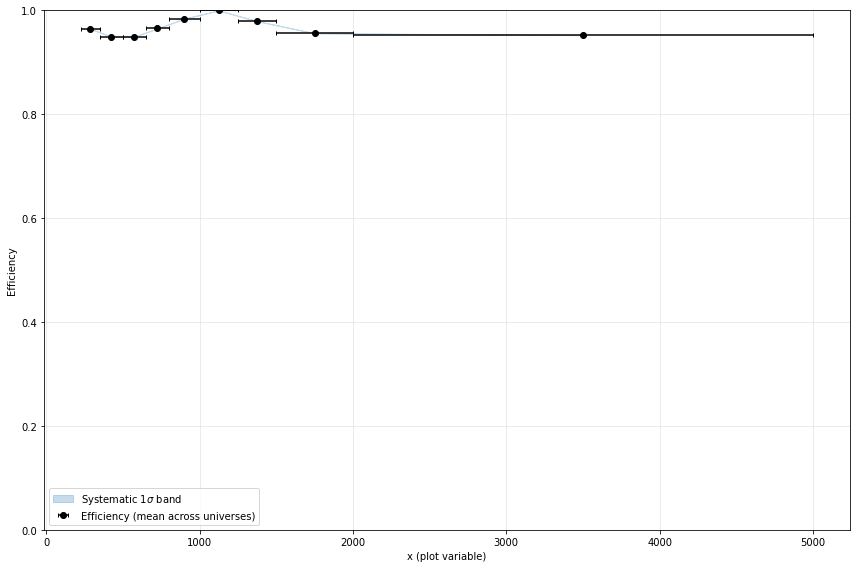

In [348]:
sigma = np.sqrt(np.clip(np.diag(CovTotal), 0.0, None))
print("Covariance matrix:", CovTotal)
print("Sigma:", sigma)
print("CV:", eff_cv)

fig, ax = plt.subplots(figsize=(12, 8))

# central values with x error bars showing bin width
ax.errorbar(
    bin_centers, eff_cv,
    xerr=bin_halfwidth,
    fmt="o", color="black",
    label="Efficiency (mean across universes)",
    capsize=2,
)

# 1σ band (diagonal-only). This is the standard “error band”.
ax.fill_between(
    bin_centers,
    eff_cv - sigma,
    eff_cv + sigma,
    color="C0", alpha=0.25,
    label=r"Systematic 1$\sigma$ band",
    step=None,
)

ax.set_xlabel("x (plot variable)")
ax.set_ylabel("Efficiency")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

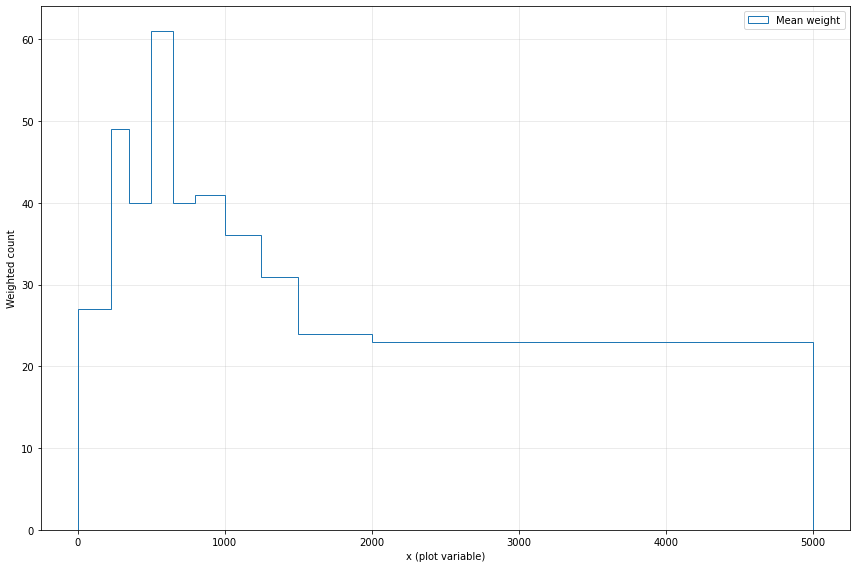

In [102]:
fig, ax = plt.subplots(figsize=(12, 8))

plt.hist(x, bins=bin_edges, weights=W.mean(axis=1), histtype='step', label='Mean weight')
ax.set_xlabel("x (plot variable)")
ax.set_ylabel("Weighted count")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()

In [51]:
x*W.mean(axis=1)

array([ 797.11757158, 1408.90723918,  330.90426327,  238.48813242,
        587.62598017,  274.85120935,  566.73392711,  270.72174138,
        643.44630492,  314.90528886,  758.15099   ,  522.93336487,
       1188.7600269 ,  443.24894802,           nan, 1182.70309295,
        386.35055567, 1804.62243335, 1247.21925735, 1407.6190138 ,
       2477.75758098, 5435.31931514,  309.15764534, 3319.17335246,
        701.91900688,  798.33206643,  784.17406731,  702.28508959,
       1251.14419816, 1413.57171165,  996.01505817,  587.10366436,
        771.68687322, 2138.59619295,  607.27193341,  555.11178781,
       1311.38066682, 1311.83665142,  251.13081608,  303.06150208,
        989.76887286,  640.77880743, 1126.20304853,  753.16273611,
          5.71860955,  208.51131923,  252.69011542,  186.16640163,
        420.51867359, 1409.97384693,  613.43337808,   31.15146748,
        715.08881373,  329.74086426,  924.18786266, 1340.42731262,
        582.09218207,  439.52884762,  913.84457155,           